In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import warnings
warnings.filterwarnings("ignore")

# Load dataset of Unemployment rates
countries = ['DE','FR','UK']
selected_rows = pd.DataFrame()

for country in countries:
    data = pd.read_excel('Data_unemp.xlsx', sheet_name=country, header=None)
    unemployment = data.iloc[1,1:].astype(float)
    selected_rows[country]=unemployment.values 

selected_rows=selected_rows.transpose()

# Caculate ADF
results ={}
for country, series in selected_rows.iterrows():
    series_clean=series.dropna().values
    adf_result = adfuller(series_clean)
    results[country] = {
        'ADF Statistic': round(adf_result[0], 4),
        'p-value': round(adf_result[1], 4),
        'Stationary': adf_result[1] < 0.05
    }

# Show results
for country,res in results.items():
    print(f"Country: {country}")
    print(f"  ADF Statistic: {res['ADF Statistic']}")
    print(f"  p-value: {res['p-value']}")
    print(f"  Stationary: {'Yes' if res['Stationary'] else 'No'}\n")


Country: DE
  ADF Statistic: -1.4125
  p-value: 0.5763
  Stationary: No

Country: FR
  ADF Statistic: -2.3459
  p-value: 0.1576
  Stationary: No

Country: UK
  ADF Statistic: -2.0397
  p-value: 0.2694
  Stationary: No



In [7]:
# Non-stationary data series suggests need for differencing or use of SARIMA-like models

# Load all country data and fit models
countries = ['UK', 'FR', 'DE']
country_names = {'UK': 'UK', 'FR': 'France', 'DE': 'Germany'}
colors = {'UK': '#C8102E', 'FR': '#0055A4', 'DE': '#000000'}

# Store results for each country
results = {}

for country in countries:
    data = pd.read_excel('Data_unemp.xlsx', sheet_name=country, header=None)
    dates = pd.to_datetime(data.iloc[0, 1:].values)
    unemp = data.iloc[1, 1:].astype(float).values / 100

    # Split data (% train data, balance% test data)
    train_size = int(len(unemp) * 0.95)
    train, test = unemp[:train_size], unemp[train_size:]
    
    # Fit SARIMA model
    model = auto_arima(train, 
                       seasonal=True, m=12,
                       max_p=3, max_q=3, max_P=2, max_Q=2,
                       max_d=2, max_D=1,
                       trace=False, error_action='ignore',
                       suppress_warnings=True, stepwise=True)
    
    # Generate forecasts and fitted values
    forecast = model.predict(n_periods=len(test))
    fitted_values = model.predict_in_sample()
    
    # Calculate RMSE
    train_rmse = sqrt(mean_squared_error(train, fitted_values))
    test_rmse = sqrt(mean_squared_error(test, forecast))
    
    results[country] = {
        'dates': dates, 'unemp': unemp,
        'train': train, 'test': test, 'train_size': train_size,
        'fitted': fitted_values, 'forecast': forecast,
        'train_rmse': train_rmse, 'test_rmse': test_rmse,
        'model_order': f"SARIMA{model.order}x{model.seasonal_order}"
    }
    
    print(f"{country_names[country]}: {results[country]['model_order']}")
    print(f"  Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}\n")

UK: SARIMA(1, 1, 3)x(0, 0, 2, 12)
  Train RMSE: 0.0042, Test RMSE: 0.0025

France: SARIMA(0, 1, 1)x(0, 0, 0, 12)
  Train RMSE: 0.0062, Test RMSE: 0.0015

Germany: SARIMA(1, 1, 2)x(0, 0, 0, 12)
  Train RMSE: 0.0053, Test RMSE: 0.0012



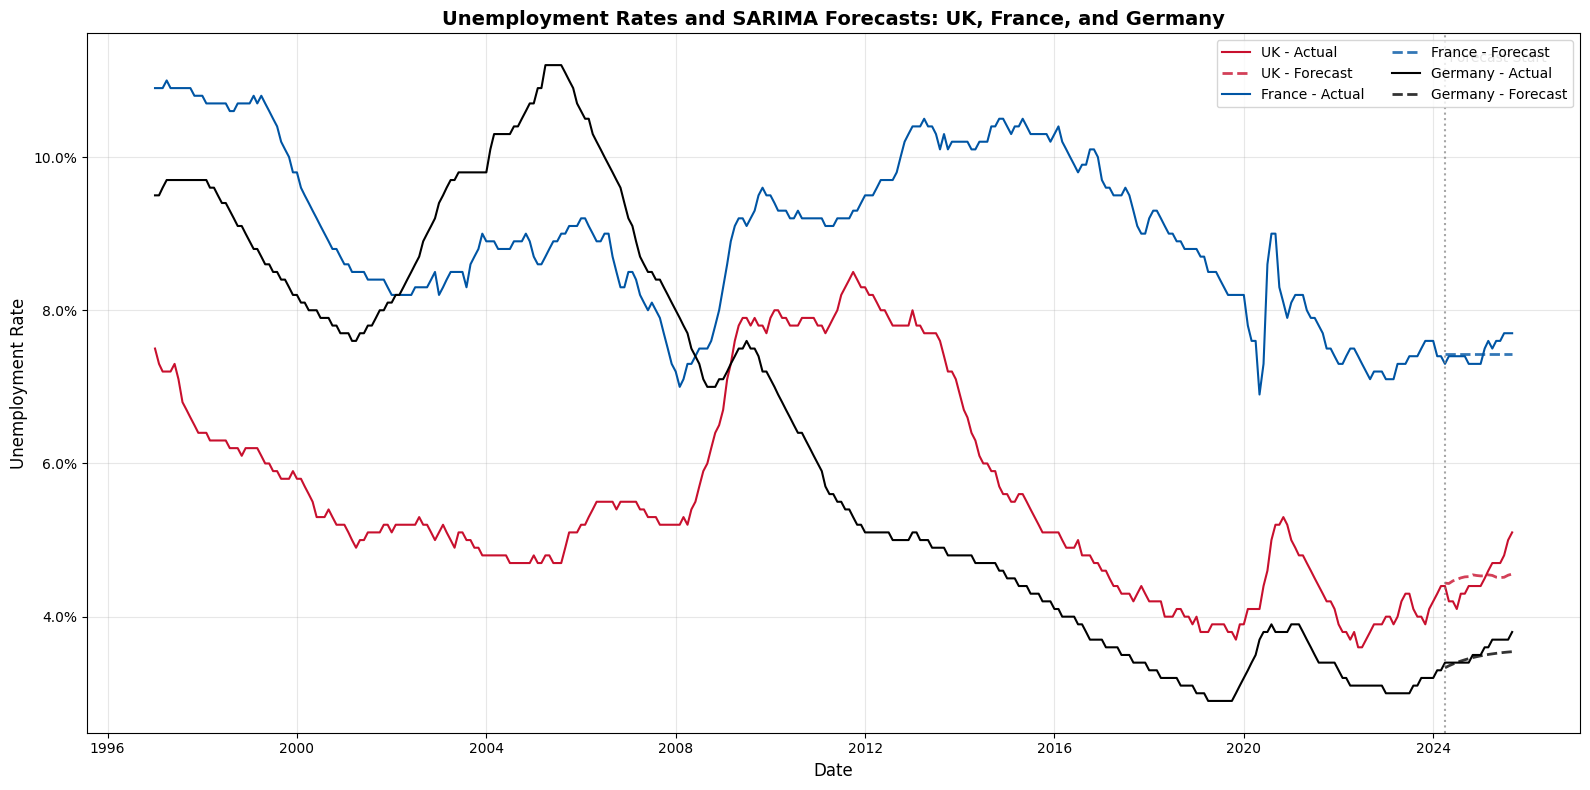

In [8]:
# Combined Plot: All Countries Unemployment Rates and Forecasts
fig, ax = plt.subplots(figsize=(16, 8))

for country in countries:
    r = results[country]
    dates = r['dates']
    train_size = r['train_size']
    test_dates = dates[train_size:]
    
    # Plot actual unemployment
    ax.plot(dates, r['unemp'], color=colors[country], linewidth=1.5,
            label=f'{country_names[country]} - Actual')
    
    # Plot forecast (dashed)
    ax.plot(test_dates, r['forecast'], color=colors[country], linewidth=2,
            linestyle='--', alpha=0.8, label=f'{country_names[country]} - Forecast')

# Add vertical line at forecast start
split_date = results['UK']['dates'][results['UK']['train_size']]
ax.axvline(x=split_date, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(split_date, ax.get_ylim()[1]*0.98, ' Forecast Start', fontsize=10, color='gray', va='top')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Unemployment Rate', fontsize=12)
ax.set_title('Unemployment Rates and SARIMA Forecasts: UK, France, and Germany',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# RMSE Comparison Table
comparison_data = []
for country in countries:
    r = results[country]
    comparison_data.append({
        'Country': country_names[country],
        'Model': r['model_order'],
        'In-Sample RMSE': r['train_rmse'],
        'Out-of-Sample RMSE': r['test_rmse'],
        'RMSE Ratio (Out/In)': r['test_rmse'] / r['train_rmse']
    })

rmse_table = pd.DataFrame(comparison_data)

# Format for display
rmse_display = rmse_table.copy()
rmse_display['In-Sample RMSE'] = rmse_display['In-Sample RMSE'].map('{:.4f}'.format)
rmse_display['Out-of-Sample RMSE'] = rmse_display['Out-of-Sample RMSE'].map('{:.4f}'.format)
rmse_display['RMSE Ratio (Out/In)'] = rmse_display['RMSE Ratio (Out/In)'].map('{:.2f}'.format)
rmse_display

,Country,Model,In-Sample RMSE,Out-of-Sample RMSE,RMSE Ratio (Out/In)
0,UK,"SARIMA(1, 1, 3)x(0, 0, 2, 12)",0.0042,0.0025,0.59
1,France,"SARIMA(0, 1, 1)x(0, 0, 0, 12)",0.0062,0.0015,0.24
2,Germany,"SARIMA(1, 1, 2)x(0, 0, 0, 12)",0.0053,0.0012,0.22


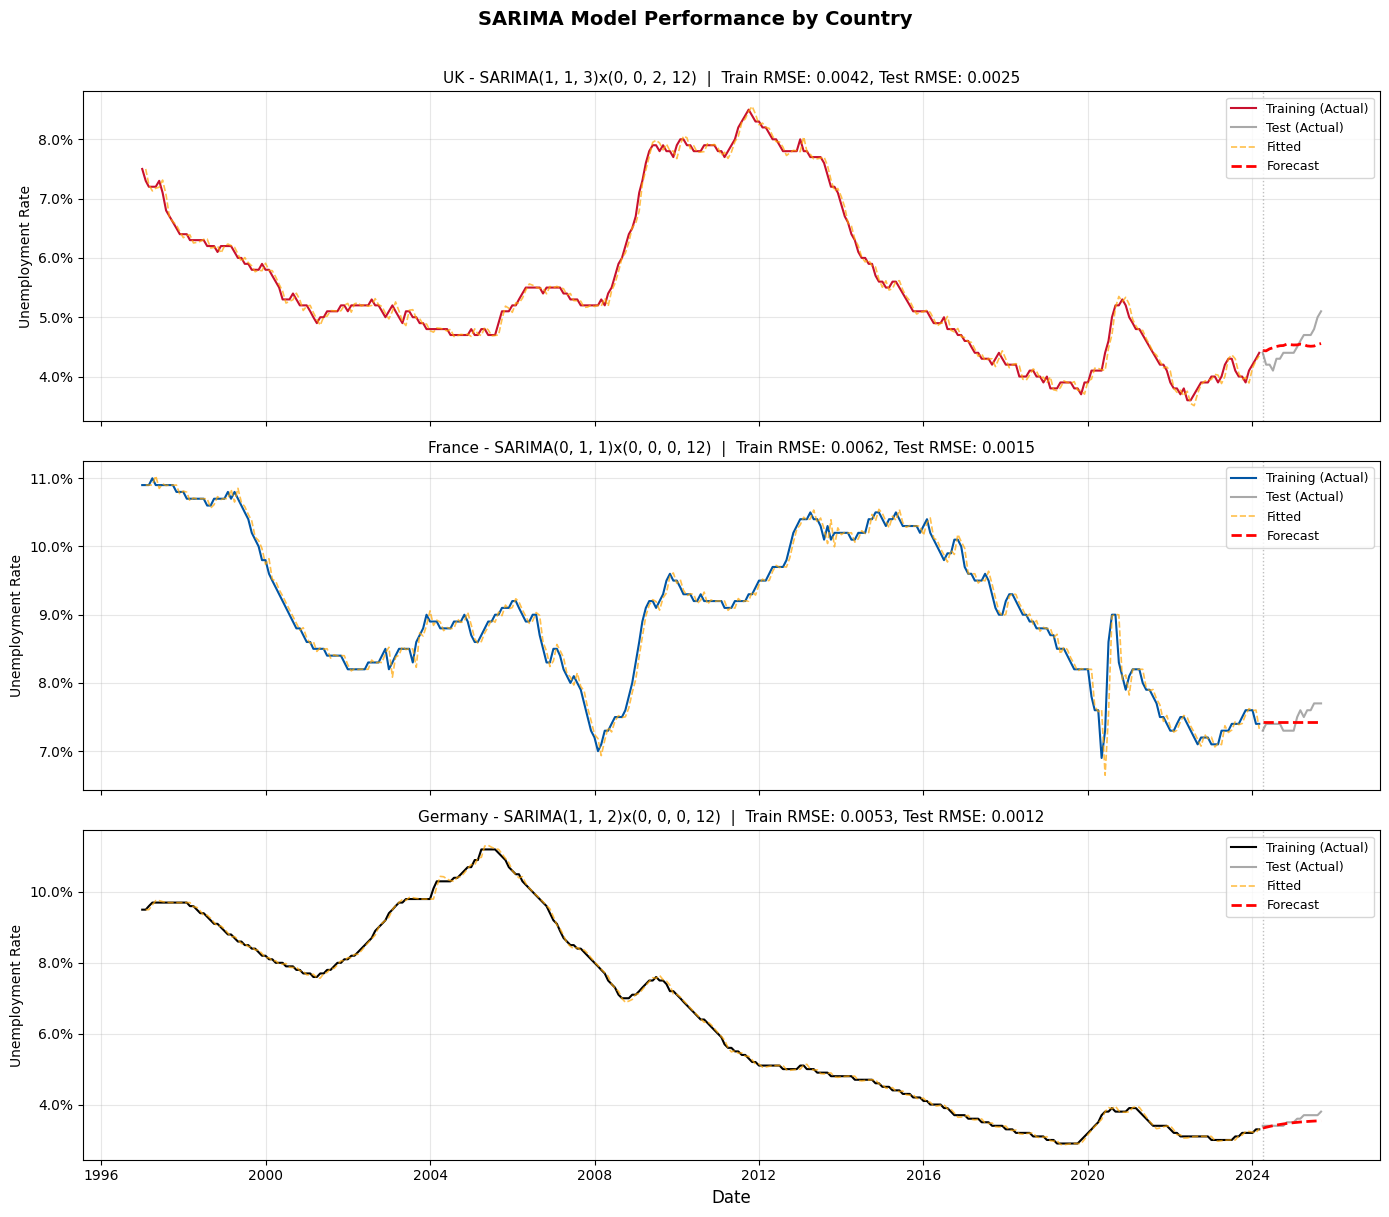

In [10]:
# Subplots: Individual Country Analysis
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
split_date = results['UK']['dates'][results['UK']['train_size']]

for idx, country in enumerate(countries):
    ax = axes[idx]
    r = results[country]
    dates = r['dates']
    train_size = r['train_size']
    train_dates, test_dates = dates[:train_size], dates[train_size:]
    
    ax.plot(train_dates, r['train'], color=colors[country], linewidth=1.5, label='Training (Actual)')
    ax.plot(test_dates, r['test'], color='darkgray', linewidth=1.5, label='Test (Actual)')
    ax.plot(train_dates[1:], r['fitted'][1:], color='orange', linewidth=1.2, linestyle='--', alpha=0.7, label='Fitted')
    ax.plot(test_dates, r['forecast'], color='red', linewidth=2, linestyle='--', label='Forecast')
    ax.axvline(x=split_date, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    ax.set_ylabel('Unemployment Rate', fontsize=10)
    ax.set_title(f"{country_names[country]} - {r['model_order']}  |  "
                 f"Train RMSE: {r['train_rmse']:.4f}, Test RMSE: {r['test_rmse']:.4f}", fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=12)
plt.suptitle('SARIMA Model Performance by Country', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()